# Task 1: Implementation of MCP Neurons:

## For ”AND” Operations.

In [47]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  # Perform an element wise addition of two input arrays stored in a new array(list):
  sum_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)]
  # Create a new array to put all the prediction let's name that a state_neuron.
  state_neuron = []
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  for s in sum_inputs:
    if s >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)

  return state_neuron

### Sample Usage for ”AND” Function.

In [48]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


## For ”OR” Operations.

In [49]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Zip combines the arrays so we can add them index by index
    sum_list = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Create a new array to put all the prediction let’s name that a state_neuron.
    state_neuron = []

    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for element_sum in sum_list:
        if element_sum >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

### Sample Usage for ”OR” Function.

In [50]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


## Answer the Following Question:



### • Question - 1: List out all the limitations of MCP - Neurons.


limitations of MCP - Neurons:

Binary Inputs and Outputs: It only works with binary values (0 or 1). It cannot handle real-valued data or continuous signals.

No learning ability:
The weights are fixed, so it cannot learn or improve from data.

Hard Thresholding: The activation function is not differentiable, which means it cannot be used with modern training algorithms like backpropagation.

No Proportionality: The neuron does check how strong the input is. It only cares if the input is "on" or "off."

Linear Separability: A single MCP neuron can only solve linearly separable problems. It cannot solve complex non-linear problems like XOR with a single unit.

---

### • Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

You cannot solve the XOR function using a single MCP neuron because XOR is not linearly separable. However, you can solve it by combining multiple neurons (Logic Gates approach).The XOR logic can be broken down into:

$(X_1 \text{ OR } X_2) \text{ AND NOT } (X_1 \text{ AND } X_2)$.

The If-Else Logic:

In [51]:
def XOR_logic(X1, X2):
    # Rule 1: Check the OR condition
    if (X1 + X2) >= 1:
        or_gate = 1
    else:
        or_gate = 0

    # Rule 2: Check the AND condition
    if (X1 + X2) >= 2:
        and_gate = 1
    else:
        and_gate = 0

    # Rule 3: XOR is true ONLY if OR-gate is true and AND-gate is false
    if or_gate == 1 and and_gate == 0:
        return 1
    else:
        return 0

---

# Task 2: Perceptron Algorithm for 0 vs 1 Classification.

## Load the Dataset:

In [52]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv") # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


## Answer the Following Question:


### 1. Question - 1: What does the shape of X represent?


The shape of X represents the dimensions of the Feature Matrix. In this dataset:

12,665 (Rows): This represents the total number of individual images. There are 12,665 handwritten digits in this specific subset.

784 (Columns): This represents the number of features per sample. Each $28 \times 28$ pixel image has been flattened into a single row of 784 pixels. Each column is the intensity of a pixel in the grid.

---

### 2. Question - 2: What does the shape of X represent?

The shape of y represents the Label Vector.

 In this dataset:

 12,665 (Length): This is a 1D array with a length matching the number of samples in $X$.

Each entry corresponds to the target output y for a specific image. A value of 0 identifies the image as a handwritten zero, and a value of 1 identifies it as a handwritten one.

## Visualize the Dataset:

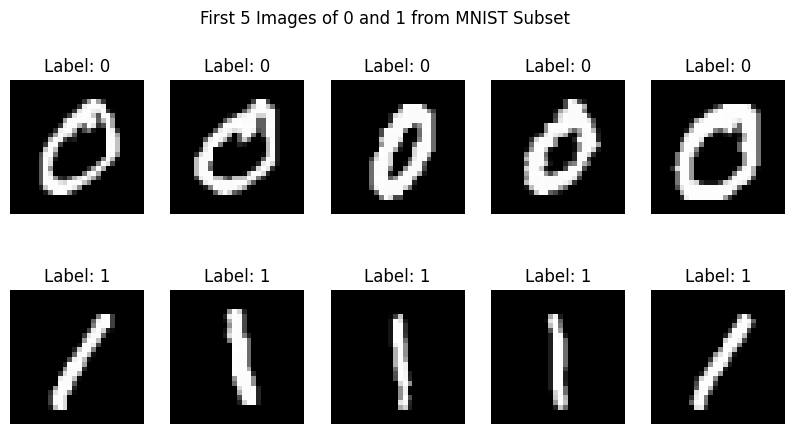

In [53]:
import matplotlib.pyplot as plt

# Separate images for label 0 and label 1
images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1


fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
    # Plot digit 0
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    # Plot digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
  plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
  plt.show()

## Initialize Weights and Bias:

In [54]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Answer the Following Question:


### 1. Question - 3: What does the weights array represent in this context?


The weights array represents the importance or strength of each individual feature (pixel) in determining the final classification (0 or 1).

Since there are 784 weights for 784 pixels, each weight $w_i$ acts as a filter for pixel $x_i$.

A positive weight suggests that the presence of a bright pixel at that location is characteristic of a 1. A negative weight suggests that a bright pixel at that location is characteristic of a 0.


The weights are used to calculate the weighted sum:$$z = \sum_{i=1}^{784} (w_i \cdot x_i) + \text{bias}$$

---

### 2. Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Initializing weights to zero provides a neutral starting point where the model initially assumes that no pixel has more influence than any other.

 For the first iteration, every input $X$ will result in a weighted sum of $0$. Once the model makes its first mistake, the Perceptron Learning Rule will  update the weights based on the input pixels and allowing the model to start distinguishing between the two digits.


## Implement a Decision Function or Activation Function:

### Implementation Decision Function:

In [55]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training
    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    # Calculate the weighted sum for all samples
    predictions = np.dot(X, weights) + bias

    # Activation function (step function)
    # This converts the raw sums into binary 0 or 1 outputs
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Implement the Perceptron Learning Algorithm:

### Training the Perceptron:

In [56]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)
    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    n_samples = X.shape[0]
    errors_history = []

    for epoch in range(epochs):
        errors = 0
        for i in range(n_samples):
            # Weighted sum + Activation
            linear_output = np.dot(X[i], weights) + bias
            y_predicted = 1 if linear_output >= 0 else 0

            # Update rule if prediction is wrong
            update = learning_rate * (y[i] - y_predicted)
            if update != 0:
                weights += update * X[i]
                bias += update
                errors += 1

        errors_history.append(errors)

        # Early stopping if converged
        if errors == 0:
            print(f"Converged at epoch {epoch+1}")
            break

    return weights, bias, errors_history

## Answer the Following Question:





### 1. Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?


This line calculates the total input to the perceptron. It multiplies each input value with its corresponding weight, adds them together, and then adds the bias. This result is used to decide whether the output will be 0 or 1.

---

### 2. Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?


When the prediction is wrong, the perceptron updates its weights and bias to improve future predictions. It adjusts them using the difference between the actual value and the predicted value. If the prediction is too low, the weights and bias are increased; if it is too high, they are decreased. This process helps the model learn from its mistakes.

----

### 3. Question - 7:Why is the final accuracy important, and what do you expect it to be?

Final accuracy is important because it shows how well the perceptron has learned from the training data. A high accuracy means the model is making correct predictions.

----

## Putting it all Together:

### Training the Perceptron Algorithm:

In [57]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Converged at epoch 13
The Final Accuracy is:  [42, 23, 17, 17, 13, 9, 3, 6, 14, 10, 6, 3, 0]


## Visualizing the Misclassified Image:

In [58]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Answer the Following Question:


### 1. Question - 8:What does misclassified_idx store, and how is it used in this code?


misclassified_idx stores the indexes of all data points where the prediction is wrong. These indexes are then used to find and display the misclassified images. The code selects up to 10 of these wrong predictions and shows them as images, along with their predicted and true labels.

---

### 2. Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?

This means the model predicted every image correctly, so there are no errors. In other words, the accuracy is 100%. It shows that the model has learned the data perfectly for this dataset.

---

# Task 3: Perceptron Algorithm for 3 vs 5 Classification.

To - Do:
1. Implement each Step as we implemented above.
2. Visualize the final misclassified images and Provide your conclusion.

## Load and Prepare the Dataset

In [59]:
# Step 1: Load and Prepare the Dataset
# Note: Ensure mnist_3_and_5.csv is in your directory
df_3_5 = pd.read_csv("mnist_3_and_5.csv")

X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

# Labels are usually 3 and 5. We need to convert them to binary (0 and 1) for the model.
# Let 3 = 0 and 5 = 1
y_binary = np.where(y == 3, 0, 1)



# visualizing the data

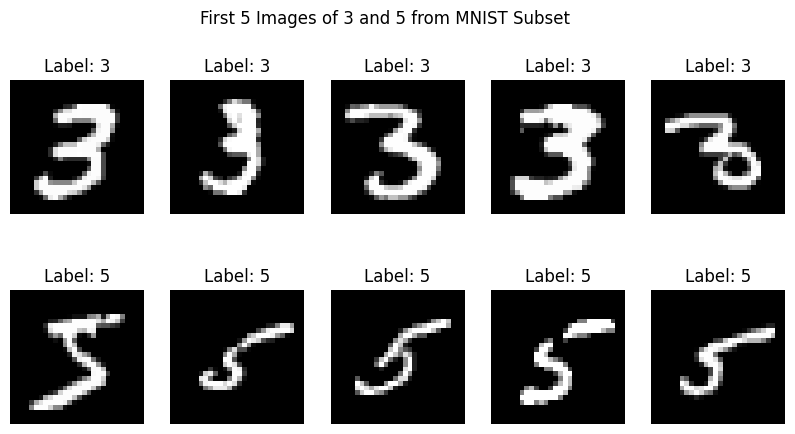

In [68]:
import matplotlib.pyplot as plt

# Separate images for label 3 and label 5
images_3 = X[y == 3] # Get all images with label 3
images_5 = X[y == 5] # Get all images with label 5


fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
  print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
  for i in range(5):
    # Plot digit 3
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    # Plot digit 5
    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")
  plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
  plt.show()

##  Initialize Parameters

In [60]:

weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100 # Perceptrons usually converge quickly



## Train the Perceptron

In [61]:

def train_perceptron(X, y, weights, bias, learning_rate, epochs):
    n_samples = X.shape[0]
    for epoch in range(epochs):
        errors = 0
        for i in range(n_samples):
            # Weighted sum + Activation
            linear_output = np.dot(X[i], weights) + bias
            y_predicted = 1 if linear_output >= 0 else 0

            # Update rule if prediction is wrong
            update = learning_rate * (y[i] - y_predicted)
            if update != 0:
                weights += update * X[i]
                bias += update
                errors += 1
        #  break if no errors (convergence)
        if errors == 0:
            break
    return weights, bias

weights, bias = train_perceptron(X, y_binary, weights, bias, learning_rate, epochs)



## Evaluate and Identify Misclassified Images

In [62]:
def get_misclassified(X, y_true, weights, bias):
    predictions = np.where((np.dot(X, weights) + bias) >= 0, 1, 0)
    misclassified_idx = np.where(predictions != y_true)[0]
    return misclassified_idx, predictions

mis_idx, all_preds = get_misclassified(X, y_binary, weights, bias)
accuracy = (len(y_binary) - len(mis_idx)) / len(y_binary)
print(f"Final Accuracy: {accuracy:.4f}")

Final Accuracy: 0.9869


## Visualize Misclassified Images

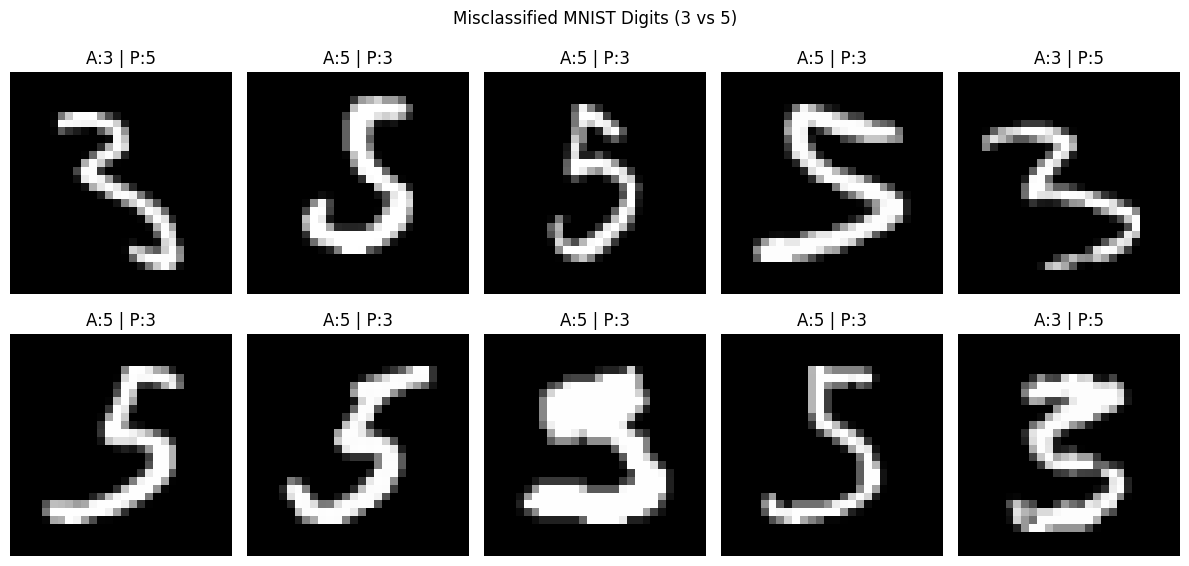

In [63]:
# Visualize first 10 misclassified images
if len(mis_idx) > 0:
    num_to_show = min(len(mis_idx), 10)
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(num_to_show):
        idx = mis_idx[i]
        axes[i].imshow(X[idx].reshape(28, 28), cmap='gray')
        # Map binary back to original labels for the title
        actual = 3 if y_binary[idx] == 0 else 5
        pred = 3 if all_preds[idx] == 0 else 5
        axes[i].set_title(f"A:{actual} | P:{pred}")
        axes[i].axis('off')

    plt.suptitle("Misclassified MNIST Digits (3 vs 5)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")